# Fig.01 input-conditioned duration stiffness（可交互调参数版）

这版专门给你调图用的 `ipynb`。

你要改宽高和间距就改第二个代码块里的参数，然后重跑最后一个画图 Cell。


In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [3]:
# 风格（和正式脚本一致）
BLUE = "#2563A6"
BLUE_LIGHT = "#9BC4E2"
ORANGE = "#D97706"
GOLD = "#C7A43A"
OLIVE = "#708238"
CHARCOAL = "#252A30"
GREY = "#7B828A"
LIGHT_GREY = "#D9DEE3"

FIG1_PANEL_ORDER = [
    "bt_smc_oof",
    "mscnn_smc_oof",
    "tcn_smc_final0",
    "bt_gtzan_seed0",
    "mscnn_gtzan",
    "tcn_gtzan_final0",
]

FIG1_STYLE = {
    "bt_smc_oof": (BLUE, "-"),
    "mscnn_smc_oof": (GOLD, "-"),
    "tcn_smc_final0": (OLIVE, "-"),
    "bt_gtzan_seed0": (BLUE, "--"),
    "mscnn_gtzan": (GOLD, "--"),
    "tcn_gtzan_final0": (OLIVE, "--"),
}

FIG1_LABEL = {
    "bt_smc_oof": "BeatThis / SMC",
    "mscnn_smc_oof": "MSCNN / SMC",
    "tcn_smc_final0": "TCN / SMC",
    "bt_gtzan_seed0": "BeatThis / GTZAN",
    "mscnn_gtzan": "MSCNN / GTZAN",
    "tcn_gtzan_final0": "TCN / GTZAN",
}

def setup_style():
    sns.set_theme(style="ticks", context="paper")
    mpl.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "font.size": 8.0,
            "axes.titlesize": 9.0,
            "axes.labelsize": 8.0,
            "xtick.labelsize": 7.2,
            "ytick.labelsize": 7.2,
            "legend.fontsize": 7.0,
            "figure.titlesize": 10.0,
            "axes.edgecolor": CHARCOAL,
            "axes.linewidth": 0.65,
            "grid.color": LIGHT_GREY,
            "grid.linewidth": 0.5,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "svg.hashsalt": "casm-mechanism-20260904",
        }
    )


def ecdf(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x = np.sort(np.asarray(values, dtype=float))
    return x, np.arange(1, len(x) + 1) / len(x)

def build_fig01_input(
    data_dir: Path,
    frozen: dict[str, object],
    *,
    figsize=(7.15, 4.15),
    height_ratios=(1.15, 0.82),
    wspace=0.34,
    hspace=0.55,
    top=0.84,
    bottom=0.14,
    left=0.13,
    right=0.97,
    # panel A
    coef_ylim=(0.0, 145.0),
    coef_xlim=(0.0, 1.0),
    # panel B
    margin_xlim=(0.0, 0.62),
    # panel C
    coeff_xlim=(0.08, 38.0),
    fallback_x=(32.0, None),
    marker_size=6.2,
    scatter_pointsize=12,
):
    edges = pd.read_csv(data_dir / "mechanism_edges.csv.gz")
    pieces = pd.read_csv(data_dir / "mechanism_piece_summary.csv")

    lam = float(frozen["duration_weight"])
    sigma0 = float(frozen["duration_sigma"])
    sigmau = float(frozen["uncertain_sigma"])

    fig = plt.figure(figsize=figsize)
    grid = fig.add_gridspec(2, 2, height_ratios=height_ratios)
    ax_curve = fig.add_subplot(grid[0, 0])
    ax_margins = fig.add_subplot(grid[0, 1])
    ax_operating = fig.add_subplot(grid[1, :])
    axes = [ax_curve, ax_margins, ax_operating]

    fig.subplots_adjust(
        wspace=wspace,
        hspace=hspace,
        top=top,
        bottom=bottom,
        left=left,
        right=right,
    )

    c = np.linspace(0.0, 1.0, 1001)
    sigma = sigma0 + (1.0 - c) * sigmau
    coefficient = lam * c / (2.0 * sigma * sigma)
    empirical_limit = float(edges.edge_margin.quantile(0.995))
    ax_curve.axvspan(0, empirical_limit, color=BLUE_LIGHT, alpha=0.24, lw=0)
    ax_curve.plot(c, coefficient, color=BLUE, lw=1.8)
    ax_curve.axvline(empirical_limit, color=GREY, lw=0.8, ls="--")
    ax_curve.text(
        empirical_limit,
        72,
        "99.5% of\nobserved edges",
        color=GREY,
        ha="left",
        va="center",
        fontsize=6.7,
    )
    for x0 in (0.1, 0.5, 1.0):
        y0 = lam * x0 / (2 * (sigma0 + (1 - x0) * sigmau) ** 2)
        ax_curve.scatter([x0], [y0], s=scatter_pointsize, color=ORANGE, zorder=3)
    ax_curve.set_xlim(*coef_xlim)
    ax_curve.set_ylim(*coef_ylim)
    ax_curve.set_xlabel("Period margin $c$")
    ax_curve.set_ylabel("Effective coefficient $w(c)$")
    ax_curve.set_title("(a) Fixed response law", loc="left", fontweight="bold")
    ax_curve.grid(axis="y")

    for panel in FIG1_PANEL_ORDER:
        group = edges[edges.panel == panel]
        x, y = ecdf(group.edge_margin.to_numpy())
        color, style = FIG1_STYLE[panel]
        ax_margins.plot(x, y, color=color, ls=style, lw=1.2, label=FIG1_LABEL[panel])
    ax_margins.set_xlim(0, margin_xlim[1])
    ax_margins.set_ylim(0, 1)
    ax_margins.set_xlabel("Observed edge margin $c_{ij}$")
    ax_margins.set_ylabel("Cumulative fraction")
    ax_margins.set_title("(b) Real edge margins", loc="left", fontweight="bold")
    ax_margins.grid()
    ax_margins.legend(
        frameon=False,
        loc="lower right",
        ncol=2,
        handlelength=2.0,
        columnspacing=0.8,
        labelspacing=0.2,
        borderaxespad=0.2,
        fontsize=5.8,
    )

    box_data = [
        pieces.loc[pieces.panel == panel, "edge_coefficient_median"].dropna().to_numpy()
        for panel in FIG1_PANEL_ORDER
    ]
    positions = np.arange(len(FIG1_PANEL_ORDER))
    box = ax_operating.boxplot(
        box_data,
        vert=False,
        positions=positions,
        widths=0.6,
        showfliers=False,
        patch_artist=True,
        medianprops={"color": CHARCOAL, "lw": 1.0},
        whiskerprops={"color": GREY, "lw": 0.7},
        capprops={"color": GREY, "lw": 0.7},
        boxprops={"facecolor": BLUE_LIGHT, "edgecolor": BLUE, "lw": 0.8},
    )
    for patch, panel in zip(box["boxes"], FIG1_PANEL_ORDER):
        color, style = FIG1_STYLE[panel]
        alpha = 0.28 if style == "-" else 0.16
        patch.set_facecolor(mpl.colors.to_rgba(color, alpha))
        patch.set_edgecolor(color)
        patch.set_linestyle(style)
    for y, panel in zip(positions, FIG1_PANEL_ORDER):
        rate = 100 * pieces.loc[pieces.panel == panel, "beat_fallback"].mean()
        xpos = fallback_x[0] if fallback_x[1] is None else fallback_x[1]
        ax_operating.text(xpos, y, f"fallback {rate:.1f}%", va="center", ha="right", fontsize=marker_size, color=GREY)
    ax_operating.set_xscale("log")
    ax_operating.set_xlim(*coeff_xlim)
    ax_operating.set_yticks(positions, [FIG1_LABEL[panel] for panel in FIG1_PANEL_ORDER])
    ax_operating.invert_yaxis()
    ax_operating.set_xlabel("Per-piece median $w(c_{ij})$ (log scale)")
    ax_operating.set_title("(c) Input-specific operating points", loc="left", fontweight="bold")
    ax_operating.grid(axis="x", which="both")

    fig.suptitle(
        "Input-conditioned duration stiffness under one Frozen-4F configuration",
        x=0.02,
        y=0.975,
        ha="left",
        fontweight="bold",
    )
    fig.text(
        0.02,
        0.02,
        "All values are derived from real decoded edges; the shaded region marks the empirical 99.5th percentile of $c_{ij}$. "
        "Each SMC series contains 217 tracks; each GTZAN series contains 993 tracks.",
        fontsize=6.4,
        color=GREY,
    )

    return fig, axes


In [8]:
ROOT = Path('/Users/hanyu/Documents/MacCodes/ICASSP2027/self-run-figures/figures-20260904-1443')
DATA_DIR = ROOT / 'data'
FIGURE_DIR = ROOT / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_STEM = 'fig01_input_conditioned_stiffness_manual_size'

protocol_path = DATA_DIR / 'protocol.json'
frozen = json.loads(protocol_path.read_text(encoding='utf-8'))['frozen_parameters']

# 你要调整的参数都在这里
FIG_SIZE = (6.0, 4.15) #(7.15, 4.15)
HEIGHT_RATIOS = (1.15, 0.82)
WSPACE = 0.34
HSPACE = 0.55
TOP = 0.84
BOTTOM = 0.14
LEFT = 0.13
RIGHT = 0.97
COEF_YLIM = (0.0, 145.0)
COEF_XLIM = (0.0, 1.0)
MARGIN_XMAX = 0.62
COEF_XLIM_C = (0.08, 38.0)


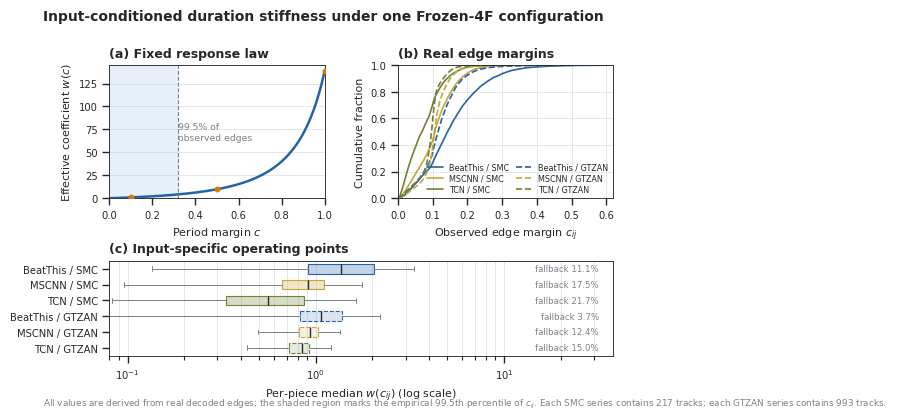

In [9]:
setup_style()
fig, axes = build_fig01_input(
    DATA_DIR,
    frozen,
    figsize=FIG_SIZE,
    height_ratios=HEIGHT_RATIOS,
    wspace=WSPACE,
    hspace=HSPACE,
    top=TOP,
    bottom=BOTTOM,
    left=LEFT,
    right=RIGHT,
    coef_ylim=COEF_YLIM,
    coef_xlim=COEF_XLIM,
    margin_xlim=(0.0, MARGIN_XMAX),
    coeff_xlim=COEF_XLIM_C,
)
plt.show()


In [ ]:
# 导出 PNG/PDF/SVG，默认保留你当前参数
out_png = FIGURE_DIR / f'{OUTPUT_STEM}.png'
out_svg = FIGURE_DIR / f'{OUTPUT_STEM}.svg'

fig.savefig(out_png, dpi=320)
fig.savefig(out_svg)
print('saved:', out_png)


saved: /Users/hanyu/Documents/MacCodes/ICASSP2027/self-run-figures/figures-20260904-1443/figures/fig01_input_conditioned_stiffness_manual_size.png
